In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_excel(r"C:\Users\hp\Downloads\UTM_Tensile_Compression_Dataset_1.xlsx",
                   sheet_name="UTM_Test_Data")

In [3]:
df.head(5)

,Sample_ID,Material,Material_Standard,Test_Type,Specimen_Diameter_mm,Cross_Sectional_Area_mm2,Original_Length_mm,Applied_Load_kN,Stress_MPa,Displacement_mm,Strain_Percent,Yield_Strength_MPa,Failure_Limit_MPa,Yielded_Flag,Fractured_Flag,Test_Temperature_C,Condition
0,UTM-0001,SS304,ASTM A240 Type 304 (annealed),Tensile,10.08,79.801480,48.96,38.400,481.194083,17.4540,35.649510,205,515,1,0,29.6,Yielded
1,UTM-0002,SS304,ASTM A240 Type 304 (annealed),Tensile,9.51,71.031488,48.70,30.508,429.499658,14.1215,28.996920,205,515,1,0,30.3,Yielded
2,UTM-0003,SS304,ASTM A240 Type 304 (annealed),Tensile,10.00,78.539816,49.15,17.470,222.434948,1.1550,2.349949,205,515,1,0,31.4,Yielded
3,UTM-0004,SS304,ASTM A240 Type 304 (annealed),Tensile,10.02,78.854290,51.13,20.578,260.962340,3.7366,7.308038,205,515,1,0,25.8,Yielded
4,UTM-0005,SS304,ASTM A240 Type 304 (annealed),Tensile,10.09,79.959895,49.04,37.163,464.770497,16.4460,33.535889,205,515,1,0,29.1,Yielded


In [4]:
df.shape

(1000, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Sample_ID                 1000 non-null   object 
 1   Material                  1000 non-null   object 
 2   Material_Standard         1000 non-null   object 
 3   Test_Type                 1000 non-null   object 
 4   Specimen_Diameter_mm      1000 non-null   float64
 5   Cross_Sectional_Area_mm2  1000 non-null   float64
 6   Original_Length_mm        1000 non-null   float64
 7   Applied_Load_kN           1000 non-null   float64
 8   Stress_MPa                1000 non-null   float64
 9   Displacement_mm           1000 non-null   float64
 10  Strain_Percent            1000 non-null   float64
 11  Yield_Strength_MPa        1000 non-null   int64  
 12  Failure_Limit_MPa         1000 non-null   int64  
 13  Yielded_Flag              1000 non-null   int64  
 14  Fractured

In [6]:
df.isnull().sum()

Sample_ID                   0
Material                    0
Material_Standard           0
Test_Type                   0
Specimen_Diameter_mm        0
Cross_Sectional_Area_mm2    0
Original_Length_mm          0
Applied_Load_kN             0
Stress_MPa                  0
Displacement_mm             0
Strain_Percent              0
Yield_Strength_MPa          0
Failure_Limit_MPa           0
Yielded_Flag                0
Fractured_Flag              0
Test_Temperature_C          0
Condition                   0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Specimen_Diameter_mm,Cross_Sectional_Area_mm2,Original_Length_mm,Applied_Load_kN,Stress_MPa,Displacement_mm,Strain_Percent,Yield_Strength_MPa,Failure_Limit_MPa,Yielded_Flag,Fractured_Flag,Test_Temperature_C
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,14.978340,195.888924,42.459440,44.355227,231.189028,2.939157,6.457920,275.500000,375307.12500,0.371000,0.063000,28.002500
std,5.008787,117.987172,7.588889,48.010222,163.250439,5.265945,11.268516,152.229017,484126.38784,0.483314,0.243085,2.339696
min,9.260000,67.346008,31.350000,1.426000,10.590764,0.001900,0.005595,205.000000,220.00000,0.000000,0.000000,24.000000
25%,10.000000,78.539816,34.950000,13.986250,105.313619,0.024000,0.063830,205.000000,501.25000,0.000000,0.000000,26.000000
50%,14.785000,184.409015,42.560000,28.575500,197.495903,0.060100,0.124902,207.000000,632.50000,0.000000,0.000000,28.000000
75%,19.980000,313.531261,49.962500,57.508250,309.523026,3.823125,8.523248,250.000000,999999.00000,1.000000,0.000000,30.100000
max,20.980000,345.701170,53.090000,258.493000,802.617917,21.124000,40.000000,675.000000,999999.00000,1.000000,1.000000,32.000000


In [9]:
df["Condition"].value_counts()

Condition
Safe         629
Yielded      308
Fractured     63
Name: count, dtype: int64

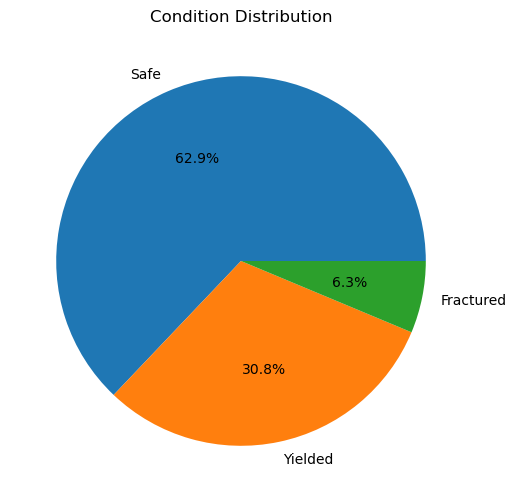

In [10]:
plt.figure(figsize=(6,6))
df["Condition"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Condition Distribution")
plt.ylabel("")
plt.show()


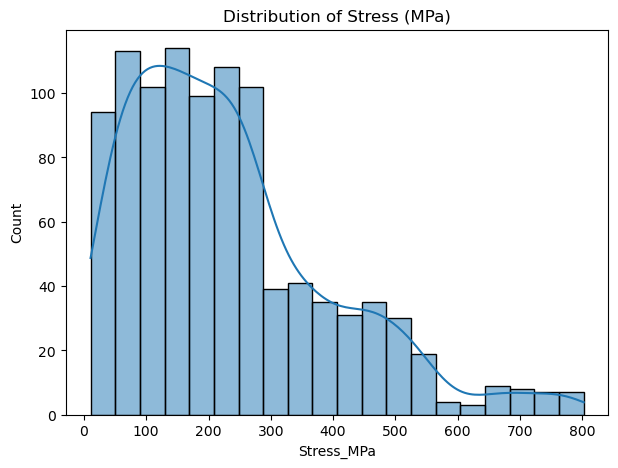

In [11]:
plt.figure(figsize=(7,5))
sns.histplot(df["Stress_MPa"], bins=20, kde=True)
plt.title("Distribution of Stress (MPa)")
plt.show()

In [12]:
df.columns

Index(['Sample_ID', 'Material', 'Material_Standard', 'Test_Type',
       'Specimen_Diameter_mm', 'Cross_Sectional_Area_mm2',
       'Original_Length_mm', 'Applied_Load_kN', 'Stress_MPa',
       'Displacement_mm', 'Strain_Percent', 'Yield_Strength_MPa',
       'Failure_Limit_MPa', 'Yielded_Flag', 'Fractured_Flag',
       'Test_Temperature_C', 'Condition'],
      dtype='object')

In [13]:
df = pd.get_dummies(
    df,
    columns=["Material", "Test_Type"],
    drop_first=True
)

In [14]:
df.head()

,Sample_ID,Material_Standard,Specimen_Diameter_mm,Cross_Sectional_Area_mm2,Original_Length_mm,Applied_Load_kN,Stress_MPa,Displacement_mm,Strain_Percent,Yield_Strength_MPa,Failure_Limit_MPa,Yielded_Flag,Fractured_Flag,Test_Temperature_C,Condition,Material_Mild Steel (IS2062 E250),Material_SS304,Material_SS316,Test_Type_Tensile
0,UTM-0001,ASTM A240 Type 304 (annealed),10.08,79.801480,48.96,38.400,481.194083,17.4540,35.649510,205,515,1,0,29.6,Yielded,False,True,False,True
1,UTM-0002,ASTM A240 Type 304 (annealed),9.51,71.031488,48.70,30.508,429.499658,14.1215,28.996920,205,515,1,0,30.3,Yielded,False,True,False,True
2,UTM-0003,ASTM A240 Type 304 (annealed),10.00,78.539816,49.15,17.470,222.434948,1.1550,2.349949,205,515,1,0,31.4,Yielded,False,True,False,True
3,UTM-0004,ASTM A240 Type 304 (annealed),10.02,78.854290,51.13,20.578,260.962340,3.7366,7.308038,205,515,1,0,25.8,Yielded,False,True,False,True
4,UTM-0005,ASTM A240 Type 304 (annealed),10.09,79.959895,49.04,37.163,464.770497,16.4460,33.535889,205,515,1,0,29.1,Yielded,False,True,False,True


In [15]:
x = df.drop(["Sample_ID","Material_Standard","Condition","Yield_Strength_MPa","Failure_Limit_MPa","Yielded_Flag","Fractured_Flag" ],axis=1)
y = df["Condition"]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=42)
print(f" Train size is :{len(x_train)}")
print(f" Test size is :{len(x_test)}")

 Train size is :800
 Test size is :200


In [16]:
df.columns

Index(['Sample_ID', 'Material_Standard', 'Specimen_Diameter_mm',
       'Cross_Sectional_Area_mm2', 'Original_Length_mm', 'Applied_Load_kN',
       'Stress_MPa', 'Displacement_mm', 'Strain_Percent', 'Yield_Strength_MPa',
       'Failure_Limit_MPa', 'Yielded_Flag', 'Fractured_Flag',
       'Test_Temperature_C', 'Condition', 'Material_Mild Steel (IS2062 E250)',
       'Material_SS304', 'Material_SS316', 'Test_Type_Tensile'],
      dtype='object')

In [17]:
numeric_column = ["Specimen_Diameter_mm", 
                  "Cross_Sectional_Area_mm2", 
                  "Original_Length_mm", 
                  "Applied_Load_kN",
                  "Stress_MPa",
                  "Displacement_mm",
                  "Strain_Percent",
                  "Test_Temperature_C"]

In [18]:
standard = StandardScaler()
x_train[numeric_column] = standard.fit_transform(x_train[numeric_column])
x_test[numeric_column] = standard.transform(x_test[numeric_column])

In [19]:
model = LogisticRegression(class_weight='balanced')
model.fit(x_train,y_train)
print("Model Trained Successfully✅")

Model Trained Successfully✅


In [20]:
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)

print("="*50)
print("      MATERIAL CONDITION CLASSIFICATION RESULTS")
print("="*50)

print(f"\nAccuracy: {accuracy:.2f} ({accuracy*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



cm = confusion_matrix(y_test, y_pred)

print("\t \t \t ------------------ Confusion Matrix ------------------\n")

print(f"{'':20}{'Predicted ' + str(model.classes_[0]):>20}{'Predicted ' + str(model.classes_[1]):>20}{'Predicted ' + str(model.classes_[2]):>20}")

print(f"{'Actual ' + str(model.classes_[0]):20}{cm[0][0]:20}{cm[0][1]:20}{cm[0][2]:20}")
print(f"{'Actual ' + str(model.classes_[1]):20}{cm[1][0]:20}{cm[1][1]:20}{cm[1][2]:20}")
print(f"{'Actual ' + str(model.classes_[2]):20}{cm[2][0]:20}{cm[2][1]:20}{cm[2][2]:20}")



      MATERIAL CONDITION CLASSIFICATION RESULTS

Accuracy: 0.94 (94.50%)

Classification Report:
              precision    recall  f1-score   support

   Fractured       0.68      1.00      0.81        17
        Safe       0.99      0.98      0.99       128
     Yielded       0.96      0.84      0.89        55

    accuracy                           0.94       200
   macro avg       0.88      0.94      0.90       200
weighted avg       0.96      0.94      0.95       200

	 	 	 ------------------ Confusion Matrix ------------------

                     Predicted Fractured      Predicted Safe   Predicted Yielded
Actual Fractured                      17                   0                   0
Actual Safe                            0                 126                   2
Actual Yielded                         8                   1                  46


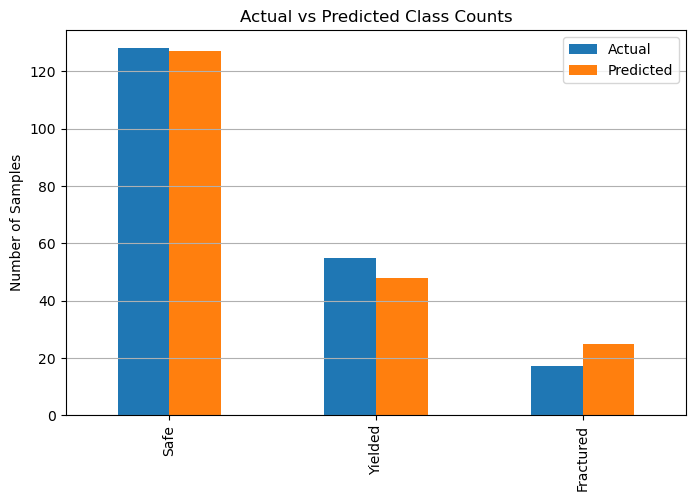

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Actual": y_test.value_counts(),
    "Predicted": pd.Series(y_pred).value_counts()
}).fillna(0)

comparison.plot(kind="bar", figsize=(8,5))

plt.title("Actual vs Predicted Class Counts")
plt.ylabel("Number of Samples")
plt.grid(axis="y")

plt.show()


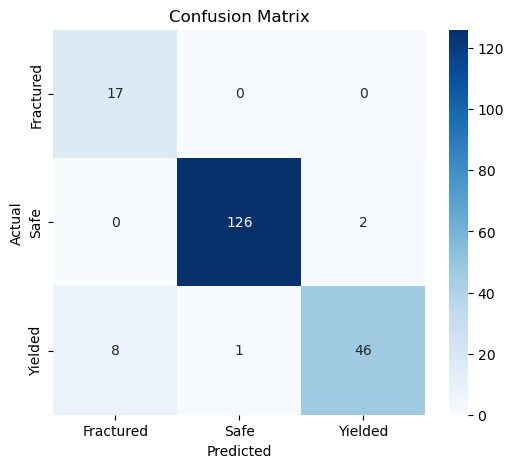

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


In [24]:
Specimen_Diameter_mm = float(input("Enter specimen diameter (mm): "))
Original_Length_mm = float(input("Enter original length (mm): "))
Applied_Load_kN = float(input("Enter applied load (kN): "))
Displacement_mm = float(input("Enter displacement (mm): "))
Test_Temperature_C = float(input("Enter room temperature (°C): "))
Material = input("Enter material (Mild Steel / SS304 / SS316): ")
Test_Type = input("Enter test type (Tensile / Compression): ")

Cross_Sectional_Area_mm2 = np.pi * (Specimen_Diameter_mm / 2) ** 2
Stress_MPa = (Applied_Load_kN * 1000) / Cross_Sectional_Area_mm2
Strain_Percent = (Displacement_mm / Original_Length_mm) * 100


user_input = pd.DataFrame({
    "Specimen_Diameter_mm": [Specimen_Diameter_mm],
    "Cross_Sectional_Area_mm2": [Cross_Sectional_Area_mm2],
    "Original_Length_mm": [Original_Length_mm],
    "Applied_Load_kN": [Applied_Load_kN],
    "Stress_MPa": [Stress_MPa],
    "Displacement_mm": [Displacement_mm],
    "Strain_Percent": [Strain_Percent],
    "Test_Temperature_C": [Test_Temperature_C],
    "Material": [Material],
    "Test_Type": [Test_Type]
})


user_input = pd.get_dummies(
    user_input,
    columns=["Material", "Test_Type"],
    dtype=int
)

user_input = user_input.reindex(
    columns=x_train.columns,
    fill_value=0
)

user_input[numeric_column] = standard.transform(
    user_input[numeric_column]
)

print("\n========== TEST DETAILS ==========")

print(f"Specimen Diameter       : {Specimen_Diameter_mm} mm")
print(f"Cross Section Area      : {Cross_Sectional_Area_mm2} mm²")
print(f"Original Length         : {Original_Length_mm} mm")
print(f"Applied Load            : {Applied_Load_kN} kN")
print(f"Stress                  : {Stress_MPa} MPa")
print(f"Displacement            : {Displacement_mm} mm")
print(f"Strain                  : {Strain_Percent} %")
print(f"Room Temperature        : {Test_Temperature_C} °C")
print(f"Material                : {Material}")
print(f"Test Type               : {Test_Type}")


prediction = model.predict(user_input)

print("\n========== PREDICTION ==========")
print(f"Predicted Condition : {prediction[0]}")



========== TEST DETAILS ==========
Specimen Diameter       : 25.0 mm
Cross Section Area      : 490.8738521234052 mm²
Original Length         : 100.0 mm
Applied Load            : 150.0 kN
Stress                  : 305.5774907364391 MPa
Displacement            : 10.0 mm
Strain                  : 10.0 %
Room Temperature        : 24.0 °C
Material                : SS304
Test Type               : Tensile

========== PREDICTION ==========
Predicted Condition : Yielded
